In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
# q7
# Load dataset
df = pd.read_csv("Risk_alert_classifier_pro3.csv")
print(df)

# Input features
X = df.drop("risk_status", axis=1)

# Target variable
y = df["risk_status"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("risk_status")

print("\nInput Shape:", X.shape)
print("Target Shape:", y.shape)

      customer_id   age  gender   region employment_type  annual_income_inr  \
0          500001  43.0  Female      NaN        Salaried            82242.0   
1          500002  29.0  Female  Central        Salaried            32769.0   
2          500003  36.0    Male     East        Salaried            39731.0   
3          500004  28.0    Male    North      Unemployed            38990.0   
4          500005  36.0  Female     East   Self-Employed            41043.0   
...           ...   ...     ...      ...             ...                ...   
4595       504596  40.0    Male    North             NaN            39337.0   
4596       504597  35.0  Female  Central      Unemployed            34465.0   
4597       504598  31.0  Female     East   Self-Employed                NaN   
4598       504599  43.0    Male     East        Salaried            15000.0   
4599       504600  43.0  Female    South        Salaried            25325.0   

      credit_score  credit_utilization_ratio  misse

In [27]:
# q8
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining Class Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Class Distribution:")
print(y_test.value_counts(normalize=True))

X_train: (3680, 18)
X_test : (920, 18)
y_train: (3680,)
y_test : (920,)

Training Class Distribution:
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64

Testing Class Distribution:
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


In [28]:
# q9

# 1. Missing values check
print("Missing Values Before Imputation:")
print(X_train.isnull().sum())

# 2. Numerical columns identify
numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# 3. KNN Imputer
imputer = KNNImputer()

# 4. Apply KNN on numerical columns
X_train[numeric_columns] = imputer.fit_transform(
    X_train[numeric_columns]
)

X_test[numeric_columns] = imputer.transform(
    X_test[numeric_columns]
)

# 5. Check missing values after imputation
print("\nMissing Values After Imputation:")
print(X_train.isnull().sum())

Missing Values Before Imputation:
customer_id                    0
age                          116
gender                         0
region                        78
employment_type              115
annual_income_inr            132
credit_score                 181
credit_utilization_ratio     118
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            110
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
dtype: int64

Missing Values After Imputation:
customer_id                    0
age                            0
gender                         0
region                        78
employment_type              115
annual_income_inr              0
credit_score                   0
credit_utilization_ratio       0
missed_payments_12m            0
avg_late_payment_days       

In [29]:
# q10

# Convert categorical columns into numbers
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Make sure both have same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Logistic Regression Model Successfully Trained!")
print("Predictions:")
print(y_pred[:5])

Logistic Regression Model Successfully Trained!
Predictions:
[0 0 0 0 0]


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[805   4]
 [  7 104]]

Accuracy : 0.9880434782608696
Precision: 0.9629629629629629
Recall   : 0.9369369369369369
F1 Score : 0.9497716894977168


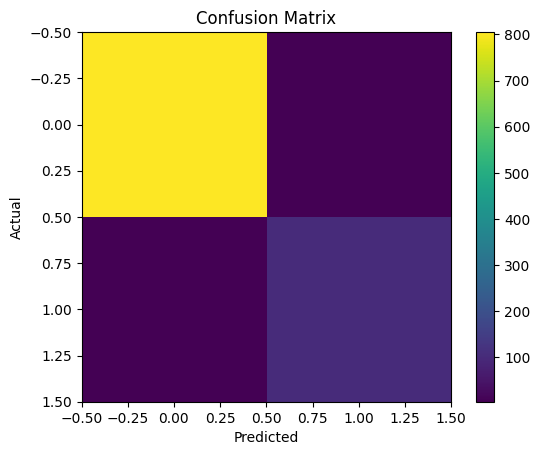

In [30]:
# Q11
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Confusion Matrix
s= confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(s)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)



plt.imshow(s)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.show()

In [31]:
# q12

# Confusion Matrix
s= confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = s.ravel()

print("Confusion Matrix:")
print(s)

print("\nTrue Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Type-I and Type-II Errors
print("\nType-I Error (False Positive):", FP)
print("Type-II Error (False Negative):", FN)

Confusion Matrix:
[[805   4]
 [  7 104]]

True Negative (TN): 805
False Positive (FP): 4
False Negative (FN): 7
True Positive (TP): 104

Type-I Error (False Positive): 4
Type-II Error (False Negative): 7


Class Distribution:
risk_status
0    4043
1     557
Name: count, dtype: int64

Class Percentage:
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


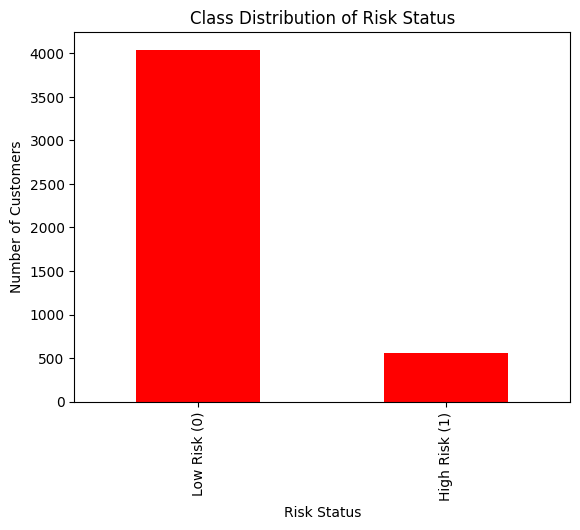

In [47]:
# q13

# Class count
print("Class Distribution:")
print(y.value_counts())

# Class percentage
print("\nClass Percentage:")
print(y.value_counts(normalize=True) * 100)

# Bar chart
y.value_counts().plot(kind="bar",color="red")

plt.title("Class Distribution of Risk Status")
plt.xlabel("Risk Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1],["Low Risk (0)", "High Risk (1)"])

plt.show()

In [ ]:
# q14
# UNDER-SAMPLING

under_sampler = RandomUnderSampler(random_state=42)

X_under, y_under = under_sampler.fit_resample(
    X_train,
    y_train
)

print("UNDER-SAMPLING")
print(y_under.value_counts())


#  OVER-SAMPLING

over_sampler = RandomOverSampler(random_state=42)

X_over, y_over = over_sampler.fit_resample(
    X_train,
    y_train
)

print("\nOVER-SAMPLING")
print(y_over.value_counts())


# SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nSMOTE")
print(y_smote.value_counts())


#  ADASYN

adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(
    X_train,
    y_train
)

print("\nADASYN")
print(y_adasyn.value_counts())

UNDER-SAMPLING
risk_status
0    446
1    446
Name: count, dtype: int64

OVER-SAMPLING
risk_status
0    3234
1    3234
Name: count, dtype: int64



SMOTE
risk_status
0    3234
1    3234
Name: count, dtype: int64

ADASYN
risk_status
0    3234
1    3226
Name: count, dtype: int64


In [ ]:
# q15 - Compare Before and After Balancing

# Features and target
X = df.drop(columns=["risk_status", "customer_id", "last_transaction_date"])
y = df["risk_status"]

# Numerical and categorical columns
num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

# Preprocessing
preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Transform data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Logistic Regression model
model = LogisticRegression(max_iter=2000)


# BEFORE BALANCING


model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("BEFORE BALANCING")
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))



# RANDOM OVERSAMPLING
ros = RandomOverSampler(random_state=42)

X_ros, y_ros = ros.fit_resample(X_train, y_train)

model.fit(X_ros, y_ros)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nRANDOM OVERSAMPLER")
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))



# SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

model.fit(X_smote, y_smote)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nSMOTE")
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))


# ADASYN

adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

model.fit(X_adasyn, y_adasyn)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nADASYN")
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


BEFORE BALANCING
Recall: 0.963963963963964
F1 Score: 0.981651376146789
AUC-ROC: 0.9999554560741211


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



RANDOM OVERSAMPLER
Recall: 1.0
F1 Score: 0.9823008849557522
AUC-ROC: 0.9999777280370605


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



SMOTE
Recall: 1.0
F1 Score: 0.9866666666666667
AUC-ROC: 0.9999777280370605

ADASYN
Recall: 1.0
F1 Score: 0.9866666666666667
AUC-ROC: 0.9999777280370605


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# q16 - Decision Tree Classifier

# Create Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train
dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9815217391304348

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       809
           1       0.95      0.89      0.92       111

    accuracy                           0.98       920
   macro avg       0.97      0.94      0.96       920
weighted avg       0.98      0.98      0.98       920



In [ ]:
# q17 - Overfitting Analysis

train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

if train_accuracy - test_accuracy > 0.05:
    print("\nModel is Overfitting")
else:
    print("\nModel is Generalizing Well")

Training Accuracy: 1.0
Testing Accuracy: 0.9815217391304348

Model is Generalizing Well


In [ ]:
# q18 - Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9978260869565218

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       1.00      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       1.00      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



In [ ]:
# q19 - Compare Decision Tree vs Random Forest

dt_train_accuracy = accuracy_score(
    y_train,
    dt_model.predict(X_train)
)

dt_test_accuracy = accuracy_score(
    y_test,
    dt_model.predict(X_test)
)


rf_train_accuracy = accuracy_score(
    y_train,
    rf_model.predict(X_train)
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_model.predict(X_test)
)


print("MODEL COMPARISON")

print("\nDecision Tree")
print("Training Accuracy:", dt_train_accuracy)
print("Testing Accuracy :", dt_test_accuracy)

print("\nRandom Forest")
print("Training Accuracy:", rf_train_accuracy)
print("Testing Accuracy :", rf_test_accuracy)

MODEL COMPARISON

Decision Tree
Training Accuracy: 1.0
Testing Accuracy : 0.9815217391304348

Random Forest
Training Accuracy: 1.0
Testing Accuracy : 0.9978260869565218


In [ ]:
# q20 - RandomizedSearchCV for Decision Tree

dt_params = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42
)

dt_random.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_random.best_params_)

print("\nBest CV AUC:")
print(dt_random.best_score_)


# RandomizedSearchCV for Random Forest
rf_params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_random.best_params_)

print("\nBest CV AUC:")
print(rf_random.best_score_)




Best Decision Tree Parameters:
{'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'entropy'}

Best CV AUC:
0.9719268741829781
Best Random Forest Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}

Best CV AUC:
0.9972254949543198


In [40]:
# q21 - GridSearchCV

grid_params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=grid_params,
    cv=5,
    scoring="roc_auc"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV AUC:")
print(grid_search.best_score_)

# best model
best_model = grid_search.best_estimator_
print(best_model)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV AUC:
0.9974513225793018
RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=200,
                       random_state=42)


In [41]:
# q22 - Tuned vs Untuned

# Untuned Random Forest
untuned_pred = rf_model.predict(X_test)

# Tuned Random Forest
tuned_pred = best_model.predict(X_test)


untuned_accuracy = accuracy_score(
    y_test,
    untuned_pred
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)


print("Untuned Random Forest Accuracy:",
      untuned_accuracy)

print("Tuned Random Forest Accuracy:",
      tuned_accuracy)

print("\nUntuned Recall:",
      recall_score(y_test, untuned_pred))

print("Tuned Recall:",
      recall_score(y_test, tuned_pred))

Untuned Random Forest Accuracy: 0.9978260869565218
Tuned Random Forest Accuracy: 0.9989130434782608

Untuned Recall: 0.9819819819819819
Tuned Recall: 0.990990990990991


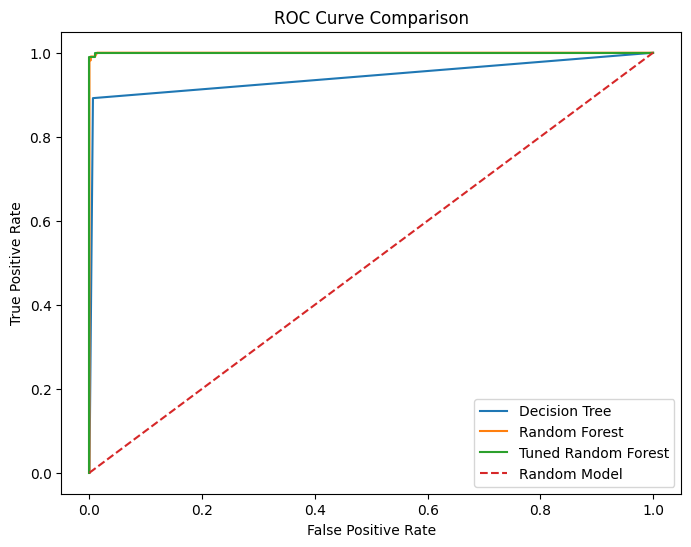

In [42]:
# q23 - ROC Curve

# Decision Tree
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Tuned Random Forest
tuned_prob = best_model.predict_proba(X_test)[:, 1]


# ROC values
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_prob)


# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label="Decision Tree"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    tuned_fpr,
    tuned_tpr,
    label="Tuned Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [43]:
# q24 - AUC ROC Comparison

dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_prob
)


print("Decision Tree AUC-ROC:",
      dt_auc)

print("Random Forest AUC-ROC:",
      rf_auc)

print("Tuned Random Forest AUC-ROC:",
      tuned_auc)

Decision Tree AUC-ROC: 0.9428557110880967
Random Forest AUC-ROC: 0.9998719362130981
Tuned Random Forest AUC-ROC: 0.9999109121482421


In [44]:
#q25 - Final Model Selection

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_model
}

for name, model in models.items():

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    recall = recall_score(
        y_test,
        prediction
    )

    f1 = f1_score(
        y_test,
        prediction
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    print("\n", name)
    print("Recall :", recall)
    print("F1     :", f1)
    print("AUC    :", auc)
    
    
    print("\nFINAL MODEL SELECTION")

best_name = None
best_recall = 0

for name, model in models.items():

    prediction = model.predict(X_test)

    recall = recall_score(
        y_test,
        prediction
    )

    if recall > best_recall:
        best_recall = recall
        best_name = name


print("Best Model:", best_name)
print("Best Recall:", best_recall)


 Decision Tree
Recall : 0.8918918918918919
F1     : 0.9209302325581395
AUC    : 0.9428557110880967

FINAL MODEL SELECTION

 Random Forest
Recall : 0.9819819819819819
F1     : 0.990909090909091
AUC    : 0.9998719362130981

FINAL MODEL SELECTION

 Tuned Random Forest
Recall : 0.990990990990991
F1     : 0.995475113122172
AUC    : 0.9999109121482421

FINAL MODEL SELECTION
Best Model: Tuned Random Forest
Best Recall: 0.990990990990991


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
0        Decision Tree  0.981522   0.951923  0.891892  0.920930  0.942856
1        Random Forest  0.997826   1.000000  0.981982  0.990909  0.999872
2  Tuned Random Forest  0.998913   1.000000  0.990991  0.995475  0.999911

BEST CLASSIFICATION MODEL
Best Model: Tuned Random Forest
Accuracy: 0.9989130434782608
Precision: 1.0
Recall: 0.990990990990991
F1 Score: 0.995475113122172
AUC-ROC: 0.9999109121482421

CONFUSION MATRIX
[[809   0]
 [  1 110]]

True Negative : 809
False Positive: 0
False Negative: 1
True Positive : 110

BUSINESS INTERPRETATION

False Positive:
A low-risk customer is incorrectly classified as high-risk.
This may cause unnecessary alerts, additional verification,
or rejection of a genuine customer.

False Negative:
A high-risk customer is incorrectly classified as low-risk.
This is more dangerous because the business may fail to
identify a risky customer and could suffer fina

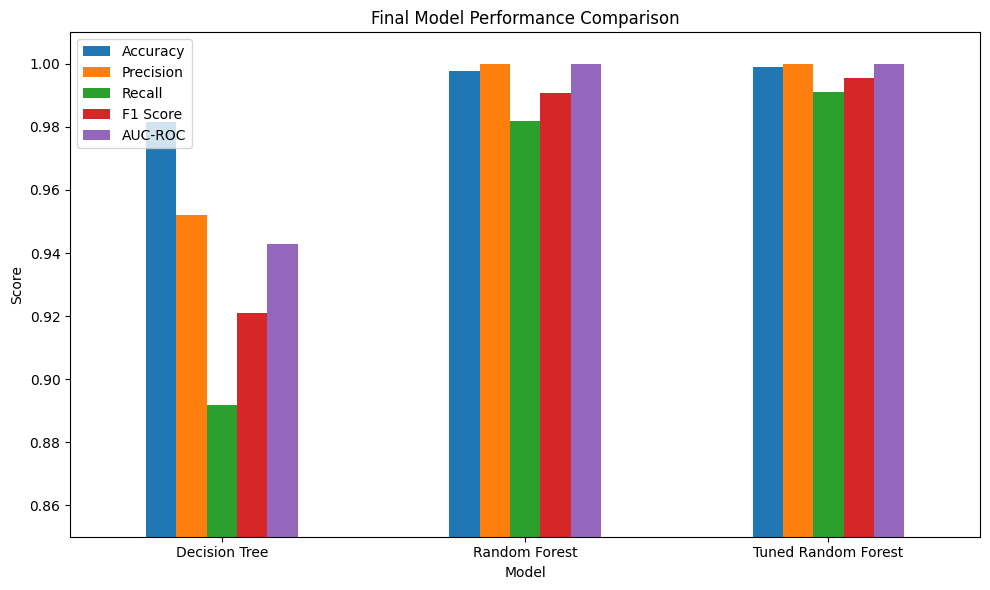

In [45]:
# q26 - FINAL ANALYSIS & REPORTING

#MODELS

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_model
}

# MODEL PERFORMANCE COMPARISON

results = []

for name, model in models.items():

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1 Score": f1_score(y_test, prediction),
        "AUC-ROC": roc_auc_score(y_test, probability)
    })


results_df = pd.DataFrame(results)

print("FINAL MODEL COMPARISON")
print(results_df)


#BEST MODEL

best_model_name = "Tuned Random Forest"

final_model = best_model

final_pred = final_model.predict(X_test)
final_prob = final_model.predict_proba(X_test)[:, 1]


print("\n========================================")
print("BEST CLASSIFICATION MODEL")
print("========================================")

print("Best Model:", best_model_name)

print("Accuracy:",
      accuracy_score(y_test, final_pred))

print("Precision:",
      precision_score(y_test, final_pred))

print("Recall:",
      recall_score(y_test, final_pred))

print("F1 Score:",
      f1_score(y_test, final_pred))

print("AUC-ROC:",
      roc_auc_score(y_test, final_prob))


#CONFUSION MATRIX

cm = confusion_matrix(y_test, final_pred)

TN, FP, FN, TP = cm.ravel()

print("\n========================================")
print("CONFUSION MATRIX")
print("========================================")

print(cm)

print("\nTrue Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)


# BUSINESS INTERPRETATION

print("\n========================================")
print("BUSINESS INTERPRETATION")
print("========================================")

print("""
False Positive:
A low-risk customer is incorrectly classified as high-risk.
This may cause unnecessary alerts, additional verification,
or rejection of a genuine customer.

False Negative:
A high-risk customer is incorrectly classified as low-risk.
This is more dangerous because the business may fail to
identify a risky customer and could suffer financial loss.

For this risk classification problem, reducing False Negatives
is very important. Therefore, Recall is an important metric.
""")

# IMBALANCE HANDLING IMPACT

print("\n========================================")
print("IMBALANCE HANDLING")
print("========================================")

print("""
Original dataset was imbalanced:

Low Risk  = 4043
High Risk = 557

Low Risk  = 87.89%
High Risk = 12.11%

Because the minority class is High Risk, accuracy alone
should not be used to judge the model.

Recall, F1 Score and AUC-ROC are important for evaluating
the ability to identify high-risk customers.
""")


# PERFORMANCE BAR CHART

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()



FINAL EVALUATION TABLE
                 Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
0        Decision Tree  0.981522   0.951923  0.891892  0.920930  0.942856
1        Random Forest  0.997826   1.000000  0.981982  0.990909  0.999872
2  Tuned Random Forest  0.998913   1.000000  0.990991  0.995475  0.999911

Evaluation table saved as:
final_model_evaluation.csv

BEST CLASSIFICATION MODEL
Best Model: Tuned Random Forest
                 Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
2  Tuned Random Forest  0.998913        1.0  0.990991  0.995475  0.999911

CONFUSION MATRIX
[[809   0]
 [  1 110]]

True Negative : 809
False Positive: 0
False Negative: 1
True Positive : 110


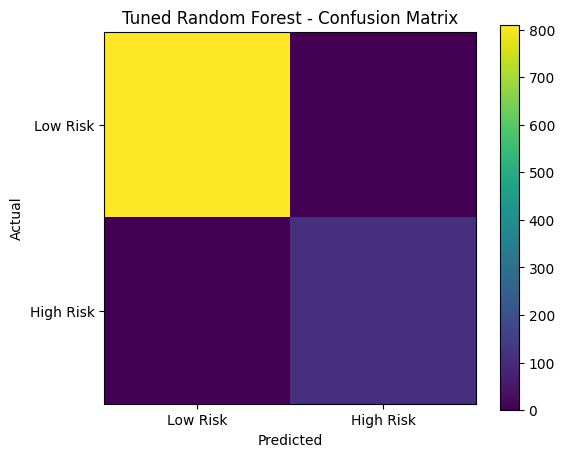

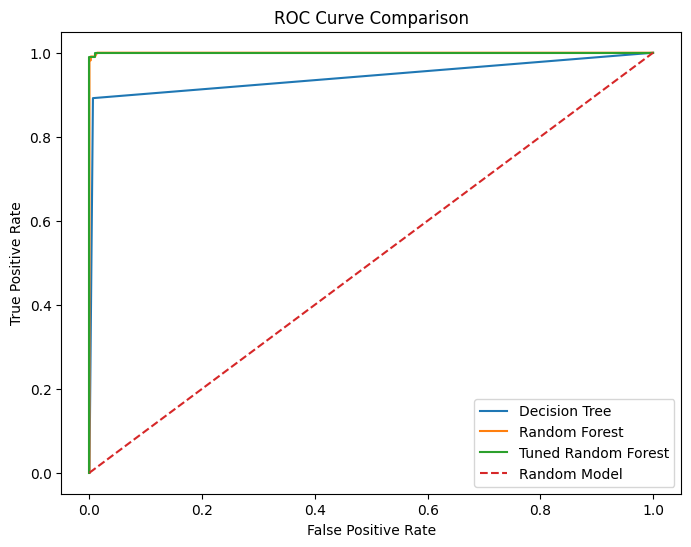


FINAL CONCLUSION

1. Decision Tree, Random Forest and Tuned Random Forest
   were evaluated.

2. Random Forest performed better than the basic
   Decision Tree.

3. Hyperparameter tuning further improved the
   Random Forest performance.

4. Tuned Random Forest is selected as the final model.

5. Recall, F1 Score and AUC-ROC were considered important
   because the dataset contains class imbalance.

6. False Negative cases are important because a high-risk
   customer incorrectly predicted as low-risk can cause
   financial loss.

7. False Positive cases may cause unnecessary verification
   or rejection of a low-risk customer.

8. The final model can be used for risk classification
   after proper monitoring and periodic retraining.


RECOMMENDATIONS

1. Use Tuned Random Forest as the final classification model.

2. Monitor Recall regularly.

3. Pay special attention to False Negative cases.

4. Do not rely only on Accuracy because the dataset is imbalanced.

5. Monitor F1 Score and 

In [46]:
#q27 - FINAL SUBMISSION


models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_model
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, prob)
    })


results_df = pd.DataFrame(results)

print("FINAL EVALUATION TABLE")
print(results_df)


# 2. SAVE EVALUATION TABLE

results_df.to_csv(
    "final_model_evaluation.csv",
    index=False
)

print("\nEvaluation table saved as:")
print("final_model_evaluation.csv")


# 3. BEST MODEL

best_model_name = "Tuned Random Forest"

print("\n====================================")
print("BEST CLASSIFICATION MODEL")
print("====================================")

print("Best Model:", best_model_name)

print(
    results_df[
        results_df["Model"] == best_model_name
    ]
)


# 4. CONFUSION MATRIX
final_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    final_pred
)

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")
print(cm)

TN, FP, FN, TP = cm.ravel()

print("\nTrue Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)


# 5. CONFUSION MATRIX PLOT

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Tuned Random Forest - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)
plt.yticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)
plt.show()

# 6. ROC CURVE
dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
tuned_prob = best_model.predict_proba(X_test)[:, 1]

dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

tuned_fpr, tuned_tpr, _ = roc_curve(
    y_test,
    tuned_prob
)


plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label="Decision Tree"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    tuned_fpr,
    tuned_tpr,
    label="Tuned Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# 7. FINAL CONCLUSION

print("\n====================================")
print("FINAL CONCLUSION")
print("====================================")

print("""
1. Decision Tree, Random Forest and Tuned Random Forest
   were evaluated.

2. Random Forest performed better than the basic
   Decision Tree.

3. Hyperparameter tuning further improved the
   Random Forest performance.

4. Tuned Random Forest is selected as the final model.

5. Recall, F1 Score and AUC-ROC were considered important
   because the dataset contains class imbalance.

6. False Negative cases are important because a high-risk
   customer incorrectly predicted as low-risk can cause
   financial loss.

7. False Positive cases may cause unnecessary verification
   or rejection of a low-risk customer.

8. The final model can be used for risk classification
   after proper monitoring and periodic retraining.
""")

#RECOMMENDATIONS
print("\n====================================")
print("RECOMMENDATIONS")
print("====================================")

print("""
1. Use Tuned Random Forest as the final classification model.

2. Monitor Recall regularly.

3. Pay special attention to False Negative cases.

4. Do not rely only on Accuracy because the dataset is imbalanced.

5. Monitor F1 Score and AUC-ROC along with Recall.

6. Retrain the model when sufficient new data becomes available.
""")


